In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# **Functions**

In [18]:
# Componentwise uniform mid‑rise quantizer for a real signal
def quantize_real(x, b, A):
    L = 2 ** b
    Delta = (2 * A) / L
    idx = np.floor(x / Delta).astype(int)
    idx = np.clip(idx, -L // 2, L // 2 - 1)
    return (idx + 0.5) * Delta

def quantize_complex(z, b, A):
    return quantize_real(z.real, b, A) + 1j * quantize_real(z.imag, b, A)

def bussgang_alpha_tau(x, q):
    P = np.mean(np.abs(x) ** 2)
    alpha = np.mean(np.conj(x) * q) / P
    tau = np.mean(np.abs(q - alpha * x) ** 2) / P
    return alpha, tau

# Quantizer Parameters Estimator
def quantizer_parameters(b, P, N = 2 ** 17):

    # Generate i.i.d. complex Gaussian input (unit power)
    rng = np.random.default_rng(0)
    x = np.sqrt(P / 2) * (np.random.randn(N) + 1j * np.random.randn(N))

    # Componentwise mid-rise quantizer with saturation
    sigma_real = np.sqrt(np.mean(np.abs(x) ** 2) / 2)
    A = 3 * sigma_real
    q = quantize_complex(x, b, A)
    alpha_tx, tau_tx = bussgang_alpha_tau(x, q)

    return alpha_tx, tau_tx

# Kullback-Leibler Divergence
def KL_Divergence(p, q):
    return np.sum(np.where(p != 0, p * np.log2(p / q), 0))

# Cummulant generating function
def cummulant_gen_func(b, P, thetas):
    # Number of quantizer levels
    L = 2 ** b
    # Quantizer Range
    sigma_re = np.sqrt(P / 2)
    A = 3 * sigma_re
    Delta = (2 * A) / L
    quantizer_levels = (np.arange(-L/2, L/2) + 0.5) * Delta

    energies = (np.add.outer(quantizer_levels**2, quantizer_levels**2)).ravel()

    theta_energy = np.outer(thetas, energies)

    # Log-sum-exp computation
    exp_terms = np.exp(theta_energy)
    lambda_S = np.log2(np.sum(exp_terms, axis=1)) - np.log2(L)

    return lambda_S

# Legendre Transform
def legendre_transform(b, p, s):
    def objective(theta):
        return -(theta * s - cummulant_gen_func(b, P, np.array([theta]))[0])

    result = minimize_scalar(objective, bounds=(-10, 10), method='bounded')
    return -result.fun

# Maximum Entropy Computation
def max_entropy(b, P, tau_tx, alpha_tx):

    # Number of quantizer levels
    L = 2 ** b
    s_tot = P * (np.abs(alpha_tx) ** 2 + tau_tx)
    H_max = np.log2(L ** 2) - legendre_transform(b, P, s_tot)
    return H_max


# Generate an OFDM‑like base‑band signal whose energy is confined to half
# of the Nyquist band (|f| < 0.25 · fs); QPSK symbols, N‑point IFFT.
def generate_inband_signal(N, rng):
    Z = np.zeros(N, dtype=complex)
    freqs = np.fft.fftfreq(N)
    active = np.where(np.abs(freqs) < 0.25)[0]          # in‑band sub‑carriers
    # random QPSK
    ph = rng.integers(0, 4, size=len(active)) * (np.pi / 2)
    Z[active] = np.exp(1j * ph)
    x = np.fft.ifft(Z) * np.sqrt(N)                     # time‑domain waveform
    return x / np.sqrt(np.mean(np.abs(x) ** 2))         # unit power

# **Fig. 2 Implementation**

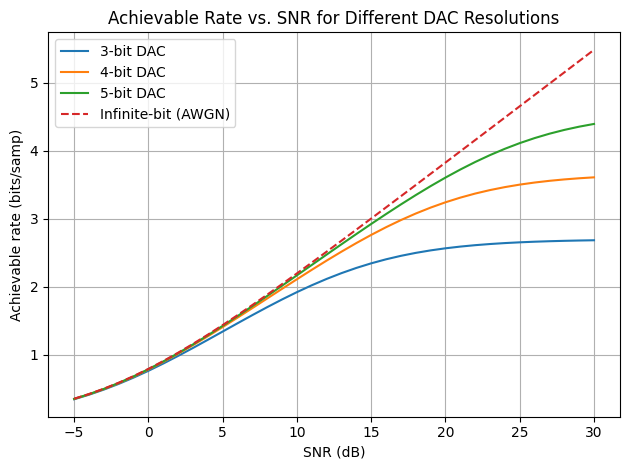

In [11]:
# Simulation parameters
P = 1.0
delta = 0.5  # Fraction of bins in sub-band 1
P1 = P / delta  # All power allocated to sub-band 1
SNR_dB = np.arange(-5, 31, 1)
sigma2 = 10 ** (-SNR_dB / 10)

# Monte Carlo sampling for Qtx statistics
bits_list = [3, 4, 5]
alpha_tx = {}
tau_tx = {}

for b in bits_list:
    # Compute alpha_tx and tau_tx
    alpha_tx[b], tau_tx[b] = quantizer_parameters(b, P)

# Compute achievable rates
rates = {}
for b in bits_list:
    rates[b] = delta * np.log2(1 + np.abs(alpha_tx[b])**2 * P1 / (tau_tx[b] * P + sigma2))

# Ideal (infinite-bit) AWGN capacity with all power in sub-band 1
rates[np.inf] = delta * np.log2(1 + P1 / sigma2)

# Plotting
plt.figure()
for b in bits_list:
    plt.plot(SNR_dB, rates[b], label=f'{b}-bit DAC')
plt.plot(SNR_dB, rates[np.inf], label='Infinite-bit (AWGN)', linestyle='--')
plt.xlabel('SNR (dB)')
plt.ylabel('Achievable rate (bits/samp)')
plt.title('Achievable Rate vs. SNR for Different DAC Resolutions')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

# **Fig. 3 Implementation**

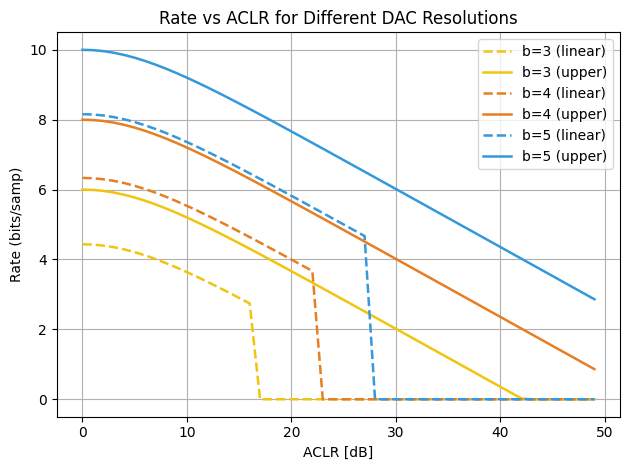

In [12]:
# Simulation parameters
P = 1.0
delta = [0.5, 0.5]  # Fraction of bins in sub-band 1 & 2
ACLR_dB = np.arange(0, 50, 1) # ACLR in dB
ACLR_linear = 10 ** (ACLR_dB / 10) # ACLR in dB
P_sub_bands = np.vstack([2 * ACLR_linear / (1 + ACLR_linear), 2 / (1 + ACLR_linear)]).T  # Energy distribution ν

# Monte Carlo sampling for Qtx statistics
bits_list = [3, 4, 5]
alpha_tx = {}
tau_tx = {}

R_lin = np.zeros((len(bits_list), len(P_sub_bands)))
R_upper = np.zeros((len(bits_list), len(P_sub_bands)))

for i, b in enumerate(bits_list):
    # Compute alpha_tx and tau_tx
    alpha_tx[b], tau_tx[b] = quantizer_parameters(b, P)

    # Total energy per symbol
    s_tot = P * (np.abs(alpha_tx[b]) ** 2 + tau_tx[b])

    # Feasibility limit
    ν2_min = delta[1] * (tau_tx[b] / (np.abs(alpha_tx[b])**2 + tau_tx[b]))          # minimum leakage fraction
    ν1_max_aclr = (1 - ν2_min) / ν2_min               # max ACLR (linear)
    treshold = ((tau_tx[b]) / (np.abs(alpha_tx[b])**2 + tau_tx[b])) * delta[1]

    for j, aclr in enumerate(ACLR_linear):
        v2 = 1 / (1 + aclr)
        v1 = aclr / (1 + aclr)
        # KL divergence D(δ||ν) in bits
        D_bits = KL_Divergence(delta, np.array([v1, v2]))

        R_upper[i, j] = 2 * b - D_bits

        if v2 >= treshold:
            # Compute achievable rates
            R_lin[i, j] = (np.log2(1 + np.abs(alpha_tx[b])**2 / tau_tx[b]) - D_bits)

        if R_upper[i, j] < 0:
            R_upper[i, j] = 0


# Plotting
colors = {3: '#F1C40F', 4: '#E67E22', 5: '#3498DB'}
linewidth = 1.8
plt.figure()
for i, b in enumerate(bits_list):
    plt.plot(ACLR_dB, R_lin[i], label=f'b={b} (linear)', color=colors[b], linewidth=linewidth, linestyle='--')
    plt.plot(ACLR_dB, R_upper[i], label=f'b={b} (upper)', color=colors[b], linewidth=linewidth)
plt.xlabel('ACLR [dB]')
plt.ylabel('Rate (bits/samp)')
plt.title('Rate vs ACLR for Different DAC Resolutions')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

# **Fig. 4 Implementation**

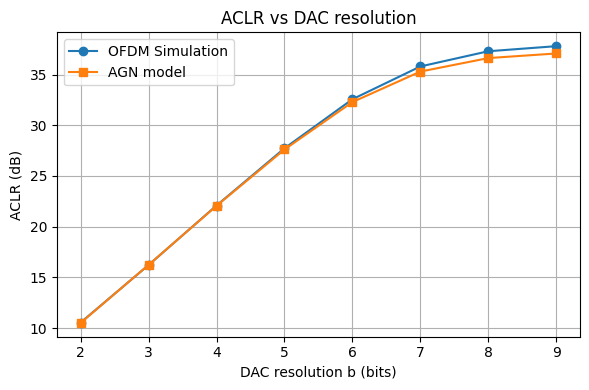

In [45]:
# Simulation parameters
rng = np.random.default_rng(0)
N        = 2 ** 16              # OFDM symbol length
bits     = np.arange(2, 10)      # DAC resolutions

# Pre‑generate the same base‑band signal for every run
x = generate_inband_signal(N, rng)
P = np.mean(np.abs(x) ** 2)

aclr_sim, aclr_theory = [], []

for b in bits:
    sigma_real = np.sqrt(P / 2)               # Std‑dev of I (or Q) part
    A = 3 * sigma_real                        # Clipping range
    q = quantize_complex(x, b, A)             # quantised samples

    # Empirical ACLR
    R = np.fft.fftshift(np.fft.fft(q)) / np.sqrt(N)
    S = np.abs(R) ** 2
    freqs = np.fft.fftshift(np.fft.fftfreq(N))
    in_band = np.abs(freqs) < 0.25          # |f| < ¼ fs
    P_in  = S[in_band].sum()
    P_adj = S[~in_band].sum()
    aclr_sim.append(10 * np.log10(P_in / P_adj))

    # AGN (Bussgang) prediction
    alpha, tau = bussgang_alpha_tau(x, q)
    aclr_theory.append(10 * np.log10(1 + 2 * (np.abs(alpha) ** 2) / tau))

# Plot
plt.figure(figsize=(6, 4))
plt.plot(bits, aclr_sim,   marker='o', label='OFDM Simulation')
plt.plot(bits, aclr_theory, marker='s', label='AGN model')
plt.xlabel('DAC resolution b (bits)')
plt.ylabel('ACLR (dB)')
plt.title('ACLR vs DAC resolution')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()